# Random Forest

In [30]:
# imports

from pathlib import Path # file paths

import numpy as np # numerical operations
import pandas as pd #csv handling

import matplotlib.pyplot as plt # plotting

from sklearn.ensemble import RandomForestClassifier # machine learning model
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV # model evaluation
# metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, 
    precision_score,
    recall_score,
    RocCurveDisplay
)

### 1. Settings

In [31]:
FEATURES_PATH = Path("outputs") / "eeg_features_data.csv"
OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

features_df = pd.read_csv(FEATURES_PATH)

print("Shape:", features_df.shape)
display(features_df.head())

print("Class distribution:")
display(features_df["Class"].value_counts())

Shape: (121, 124)


,ID,Class,n_samples,duration_sec,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
0,v10p,ADHD,14304,111.750000,20764.347948,4433.165153,1163.116779,1220.075523,3.633517,19985.184042,...,5839.205234,1832.689764,2206.839430,2033.163635,0.901398,5313.211114,2515.280960,1239.193542,2047.478172,1.228478
1,v12p,ADHD,17604,137.531250,35697.951547,7797.099598,1427.690126,1028.902332,7.578076,29986.175718,...,23000.755768,3191.807975,1139.959981,908.476562,3.513363,9076.262423,3731.706544,1414.186873,2011.651626,1.855046
2,v14p,ADHD,17562,137.203125,124322.835760,34554.128417,4828.326846,5765.890863,5.992852,198052.819591,...,32551.843934,5516.419259,2188.738526,2493.216978,2.212571,21449.856904,6070.162746,2775.817586,3659.736876,1.658634
3,v15p,ADHD,43252,337.906250,25609.106999,7425.362020,2163.548768,1443.360033,5.144497,21041.122924,...,13208.390881,3255.140409,2278.065705,1660.059682,1.960857,14728.933087,4269.300202,1999.343488,1661.070205,2.570211
4,v173,ADHD,24241,189.382812,6962.611895,3144.051753,1982.601543,6955.012349,0.452056,7648.534786,...,2837.889255,1387.619299,730.351150,2373.689547,0.584583,5284.728897,2475.850442,1332.758218,4059.060983,0.609956


Class distribution:


Class
ADHD       61
Control    60
Name: count, dtype: int64

In [32]:
def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside outputs/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside outputs/tabs.
    """
    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)

In [33]:
# Pretty names for plots

FEATURE_LABELS = {
    "frontal_theta_power_mean": "Frontal " r"${\theta}$ power",
    "frontal_beta_power_mean": "Frontal " r"${\beta}$ power",
    "frontal_theta_beta_ratio": "Frontal " r"${\theta}/{\beta}$ ratio",
    "occipital_beta_power_mean": "Occipital " r"${\beta}$ power",
    "temporal_theta_beta_ratio": "Temporal " r"${\theta}/{\beta}$ ratio",
    "occipital_theta_beta_ratio": "Occipital " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "central_theta_beta_ratio": "Central " r"${\theta}/{\beta}$ ratio",
    "T7_theta_beta_ratio": "T7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "O1_theta_beta_ratio": "O1 " r"${\theta}/{\beta}$ ratio",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "temporal_theta_power_mean": "Temporal " r"${\theta}$ power",
    "temporal_beta_power_mean": "Temporal " r"${\beta}$ power",
    "occipital_theta_power_mean": "Occipital " r"${\theta}$ power",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_delta_power_mean": "Parietal " r"${\delta}$ power",
    "Pz_theta_power_mean": "Pz " r"${\theta}$ power",
    "Pz_beta_power_mean": "Pz " r"${\beta}$ power",
    "Pz_delta_power_mean": "Pz " r"${\delta}$ power",
    "Pz_delta_power":"Pz " r"${\delta}$ power",
    "F4_theta_power": "F4 " r"${\theta}$ power",
    "F4_beta_power": "F4 " r"${\beta}$ power",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_power": "F7 " r"${\theta}$ power",
    "F7_beta_power": "F7 " r"${\beta}$ power",
    "F3_theta_power": "F3 " r"${\theta}$ power",
    "F3_beta_power": "F3 " r"${\beta}$ power",
    "C3_theta_power": "C3 " r"${\theta}$ power",
    "C3_beta_power": "C3 " r"${\beta}$ power",
    "P3_theta_power": "P3 " r"${\theta}$ power",
    "P3_beta_power": "P3 " r"${\beta}$ power",
    "T8_theta_power": "T8 " r"${\theta}$ power",
    "T8_beta_power": "T8 " r"${\beta}$ power",
    "F8_theta_power": "F8 " r"${\theta}$ power",
    "F8_beta_power": "F8 " r"${\beta}$ power",
    "O2_theta_power": "O2 " r"${\theta}$ power",
    "O2_beta_power": "O2 " r"${\beta}$ power",
    "C4_theta_power": "C4 " r"${\theta}$ power",
    "C4_beta_power": "C4 " r"${\beta}$ power",
    "Fp1_theta_power": "Fp1 " r"${\theta}$ power",
    "Fp1_beta_power": "Fp1 " r"${\beta}$ power",
    "Pz_theta_power": "Pz " r"${\theta}$ power",
    "Pz_beta_power": "Pz " r"${\beta}$ power",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "duration_sec": "Recording duration (s)",
    "n_samples": "Number of samples",
    "id": "ID",
    "class": "Class",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_power": "P7 " r"${\theta}$ power",
    "P7_beta_power": "P7 " r"${\beta}$ power",
    "P7_delta_power": "P7 " r"${\delta}$ power",
    "occipital_delta_power_mean": "Occipital " r"${\delta}$ power",
    "central_theta_power_mean": "Central " r"${\theta}$ power",
    "central_beta_power_mean": "Central " r"${\beta}$ power",
    "central_alpha_power_mean": "Central " r"${\alpha}$ power",
    "parietal_alpha_power_mean": "Parietal " r"${\alpha}$ power",
    "frontal_alpha_power_mean": "Frontal " r"${\alpha}$ power",
    "temporal_delta_power_mean": "Temporal " r"${\delta}$ power",
    "central_delta_power_mean": "Central " r"${\delta}$ power",
    "temporal_alpha_power_mean": "Temporal " r"${\alpha}$ power",

}

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

### 2. Dataset preprocessing

### 2a. Train/test split

Before training the machine learning model, the dataset is divided into two separate parts: a training/validation set and an independent test set.

The training/validation set was used to compare different feature sets and to perform cross-validation. The independent test set was kept untouched during model selection and was used only once at the end for the final evaluation.

This separation is made to avoid data leakage.

In this analysis, 80% of the subjects were assigned to the training/validation set and 20% to the final test set. In the split the proportion of ADHD and Control subjects was preserved in both subsets.

### 2b. Cross Validation

Model comparison was performed using stratified 5-fold cross-validation on the training/validation set only.

In 5-fold cross-validation, the training/validation set is divided into five folds. At each iteration, the model is trained on four folds and validated on the remaining fold. This process is repeated five times, so that each fold is used once as validation data.

Cross-validation was used to compare the three feature sets:

1. all EEG features;
2. channel-level features only;
3. regional mean features only.

The independent test set was not used during cross-validation. It was kept aside and used only after selecting the best-performing feature set.




In [34]:
# train/test split

train_df, test_df = train_test_split(
    features_df,
    test_size=0.20,
    stratify=features_df["Class"],
    random_state=42
)

print("Train/validation shape:", train_df.shape)
print("Final test shape:", test_df.shape)

print("\nTrain/validation class distribution:")
display(train_df["Class"].value_counts())

print("\nFinal test class distribution:")
display(test_df["Class"].value_counts())

Train/validation shape: (96, 124)
Final test shape: (25, 124)

Train/validation class distribution:


Class
Control    48
ADHD       48
Name: count, dtype: int64


Final test class distribution:


Class
ADHD       13
Control    12
Name: count, dtype: int64

In [35]:
# define target variable

y_train = train_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

y_test = test_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

print("Train labels:")
display(y_train.value_counts())

print("Test labels:")
display(y_test.value_counts())

Train labels:


Class
0    48
1    48
Name: count, dtype: int64

Test labels:


Class
1    13
0    12
Name: count, dtype: int64

In [36]:
# features columns

metadata_cols = [
    "ID",
    "Class",
    "n_samples",
    "duration_sec"
]

all_feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

all_feature_cols = [
    c for c in all_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[c])
]

print("All EEG features:", len(all_feature_cols))

All EEG features: 120


In [37]:
# separate channel-level features from global features 

channel_feature_cols = [
    c for c in all_feature_cols
    if not (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

print("Channel-level features:", len(channel_feature_cols))
print(channel_feature_cols[:10])

Channel-level features: 95
['Fp1_delta_power', 'Fp1_theta_power', 'Fp1_alpha_power', 'Fp1_beta_power', 'Fp1_theta_beta_ratio', 'Fp2_delta_power', 'Fp2_theta_power', 'Fp2_alpha_power', 'Fp2_beta_power', 'Fp2_theta_beta_ratio']


In [38]:
# separate regional mean features

regional_feature_cols = [
    c for c in all_feature_cols
    if (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

print("Regional mean features:", len(regional_feature_cols))
print(regional_feature_cols)

Regional mean features: 25
['frontal_delta_power_mean', 'frontal_theta_power_mean', 'frontal_alpha_power_mean', 'frontal_beta_power_mean', 'frontal_theta_beta_ratio', 'central_delta_power_mean', 'central_theta_power_mean', 'central_alpha_power_mean', 'central_beta_power_mean', 'central_theta_beta_ratio', 'parietal_delta_power_mean', 'parietal_theta_power_mean', 'parietal_alpha_power_mean', 'parietal_beta_power_mean', 'parietal_theta_beta_ratio', 'temporal_delta_power_mean', 'temporal_theta_power_mean', 'temporal_alpha_power_mean', 'temporal_beta_power_mean', 'temporal_theta_beta_ratio', 'occipital_delta_power_mean', 'occipital_theta_power_mean', 'occipital_alpha_power_mean', 'occipital_beta_power_mean', 'occipital_theta_beta_ratio']


### 3. Random Forest

After exploring the EEG features statistically in *1b_features_exploration*, a Random Forest classifier was used to evaluate whether the extracted features can distinguish ADHD subjects from Control subjects and to classify the importance fo the features.

Three different feature sets were compared:

1. all EEG features;
2. channel-level features only;
3. regional mean features only.

This comparison allows us to investigate whether classification performance is driven mainly by detailed electrode-level information or by broader regional EEG patterns.

### 4. Classification metrics
Several metrics were used to evaluate the Random Forest classifier.

### 4a. Accuracy and balanced accuracy

Accuracy measures the proportion of correctly classified subjects:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

where $TP$ are true positives, $TN$ are true negatives, $FP$ are false positives, and $FN$ are false negatives.

However, accuracy can be misleading when the classes are imbalanced. For this reason, balanced accuracy was also used.

Balanced accuracy is the average of sensitivity and specificity:

$$
Balanced\ Accuracy = \frac{Sensitivity + Specificity}{2}
$$

where sensitivity measures the proportion of correctly identified ADHD subjects, and specificity measures the proportion of correctly identified Control subjects.

In this project thw two groups are actually balanced, so the two metrics shouldn't differ.

### 4b. Precision, recall and F1-score

Precision and recall describe different aspects of classification performance.

Precision measures how many subjects predicted as ADHD are actually ADHD:

$$
Precision = \frac{TP}{TP + FP}
$$

A high precision means that when the model predicts ADHD, it is often correct.

Recall, also called sensitivity, measures how many true ADHD subjects are correctly detected:

$$
Recall = \frac{TP}{TP + FN}
$$

A high recall means that the model correctly identifies most ADHD subjects.

The F1-score combines precision and recall into a single metric:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

### 4c. ROC-AUC

ROC-AUC evaluates how well the classifier separates the two classes across different decision thresholds.

The ROC curve plots the true positive rate against the false positive rate for different threshold values. The area under this curve is called ROC-AUC.

A ROC-AUC value of:

$$
0.5
$$

indicates performance similar to random guessing, while a value close to:

$$
1.0
$$

indicates excellent separation between the two classes.

### 4d. Confusion matrix

The confusion matrix provides a direct view of the model predictions.
This matrix makes it possible to see whether the model makes more errors in one class than the other.







In [39]:
# define model
rf_model = RandomForestClassifier(
    n_estimators=500, # number of trees in the forest
    max_depth=None, # allow trees to grow until all leaves are pure or until they contain less than min_samples_leaf samples
    min_samples_leaf=2, # minimum number of samples required to be at a leaf node
    random_state=42,# reproducibility
    class_weight="balanced" # handle class imbalance using weights proportional to class frequencies 
)

# cross-validation
cv = StratifiedKFold(
    n_splits=5, # number of folds
    shuffle=True, # shuffle data before splitting 
    random_state=42 # reproducibility
)

In [40]:
def evaluate_feature_set(feature_set_name, feature_cols):
    """
    Evaluate a Random Forest classifier using cross-validation
    only on the training/validation set.
    """

    X_train = train_df[feature_cols]

    scoring = [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc",
        "precision",
        "recall"
    ]

    cv_results = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),

        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),

        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),

        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),

        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),

        "precision_mean": cv_results["test_precision"].mean(),
        "precision_std": cv_results["test_precision"].std(),

        "recall_mean": cv_results["test_recall"].mean(),
        "recall_std": cv_results["test_recall"].std()
    }

    return result

In [41]:
rf_results = []

rf_results.append(
    evaluate_feature_set(
        "All EEG features",
        all_feature_cols
    )
)

rf_results.append(
    evaluate_feature_set(
        "Channel-level features",
        channel_feature_cols
    )
)

rf_results.append(
    evaluate_feature_set(
        "Regional mean features",
        regional_feature_cols
    )
)

rf_results_df = pd.DataFrame(rf_results)

save_table(
    rf_results_df,
    "2a_rf_feature_set_comparison.csv"
)

display(rf_results_df)

Table saved to: outputs\tabs\2a_rf_feature_set_comparison.csv


,feature_set,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std
0,All EEG features,120,0.675789,0.073353,0.676667,0.075310,0.699043,0.062402,0.673778,0.094149,0.659744,0.080831,0.751111,0.082132
1,Channel-level features,95,0.613684,0.058191,0.610000,0.062991,0.646053,0.041228,0.681111,0.058119,0.603645,0.055569,0.706667,0.085664
2,Regional mean features,25,0.675789,0.119352,0.677778,0.112930,0.699952,0.093135,0.728889,0.091786,0.670000,0.113725,0.748889,0.105081


Figure saved to: outputs\figures\2a_rf_feature_set_comparison.png


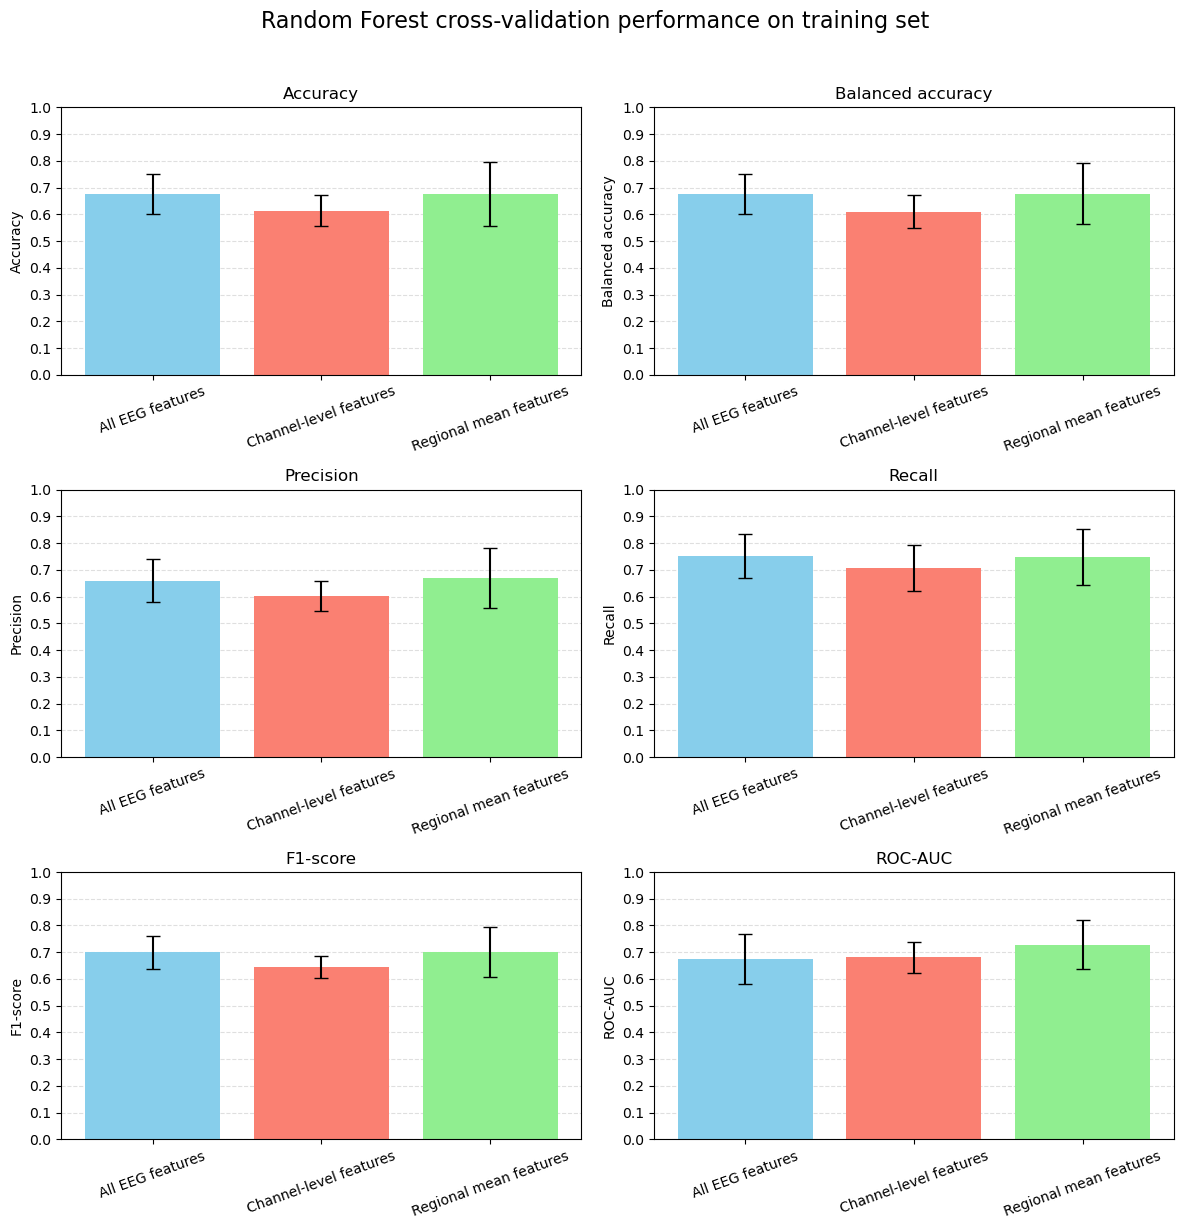

In [42]:
# Metrics to plot for feature set comparison

metrics_to_plot = {
    "Accuracy": ("accuracy_mean", "accuracy_std"),
    "Balanced accuracy": ("balanced_accuracy_mean", "balanced_accuracy_std"),
    "Precision": ("precision_mean", "precision_std"),
    "Recall": ("recall_mean", "recall_std"),
    "F1-score": ("f1_mean", "f1_std"),
    "ROC-AUC": ("roc_auc_mean", "roc_auc_std"),
}

n_metrics = len(metrics_to_plot)
n_cols = 2
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "Random Forest cross-validation performance on training set",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten()

for ax, (metric_name, (mean_col, std_col)) in zip(axes, metrics_to_plot.items()):

    ax.bar(
        rf_results_df["feature_set"],
        rf_results_df[mean_col],
        yerr=rf_results_df[std_col],
        capsize=5,
        color =["skyblue", "salmon", "lightgreen"]
    )

    ax.set_title(metric_name)
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.1))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.set_yticks(
        np.arange(0, 1.01, 0.1)
    )

for ax in axes[n_metrics:]:
    ax.axis("off")

plt.tight_layout()
save_figure("2a_rf_feature_set_comparison.png")
plt.show()

In [43]:
best_row = rf_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

best_feature_set_name = best_row["feature_set"]

print("Best feature set:")
print(best_feature_set_name)

if best_feature_set_name == "All EEG features":
    best_feature_cols = all_feature_cols

elif best_feature_set_name == "Channel-level features":
    best_feature_cols = channel_feature_cols

elif best_feature_set_name == "Regional mean features":
    best_feature_cols = regional_feature_cols

print("Number of selected features:", len(best_feature_cols))

Best feature set:
Regional mean features
Number of selected features: 25


### 5. Best feature set


In [44]:
### 4. Hyperparameter tuning on the best feature set

X_train_best = train_df[best_feature_cols]
X_test_best = test_df[best_feature_cols]

param_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None]
}

base_rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    estimator=base_rf_model,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train_best,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation balanced accuracy:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 300}

Best cross-validation balanced accuracy:
0.7088888888888889


In [45]:
tuning_results_df = pd.DataFrame(grid_search.cv_results_)

tuning_results_df = tuning_results_df.sort_values(
    "rank_test_score"
)

save_table(
    tuning_results_df,
    "2a_rf_hyperparameter_tuning_results.csv"
)

best_params_df = pd.DataFrame([grid_search.best_params_])
best_params_df["best_cv_balanced_accuracy"] = grid_search.best_score_

save_table(
    best_params_df,
    "2a_rf_best_hyperparameters.csv"
)

display(best_params_df)

Table saved to: outputs\tabs\2a_rf_hyperparameter_tuning_results.csv
Table saved to: outputs\tabs\2a_rf_best_hyperparameters.csv


,max_depth,max_features,min_samples_leaf,n_estimators,best_cv_balanced_accuracy
0,None,log2,1,300,0.708889


In [46]:
X_train_final = X_train_best
X_test_final = X_test_best

final_rf_model = grid_search.best_estimator_

final_rf_model.fit(
    X_train_best,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_features='log2',
                       n_estimators=300, random_state=42)

In [47]:
y_test_pred = final_rf_model.predict(X_test_final)
y_test_proba = final_rf_model.predict_proba(X_test_final)[:, 1]

final_test_results = {
    "feature_set": best_feature_set_name,
    "n_features": len(best_feature_cols),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "f1": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    "precision": precision_score(y_test, y_test_pred),
    "recall": recall_score(y_test, y_test_pred)

}

final_test_results_df = pd.DataFrame([final_test_results])
save_table(final_test_results_df,"2a_rf_best_feature_set_final_metrics.csv")

display(final_test_results_df)

Table saved to: outputs\tabs\2a_rf_best_feature_set_final_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,f1,roc_auc,precision,recall
0,Regional mean features,25,0.76,0.75641,0.785714,0.717949,0.733333,0.846154


Figure saved to: outputs\figures\2a_rf_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

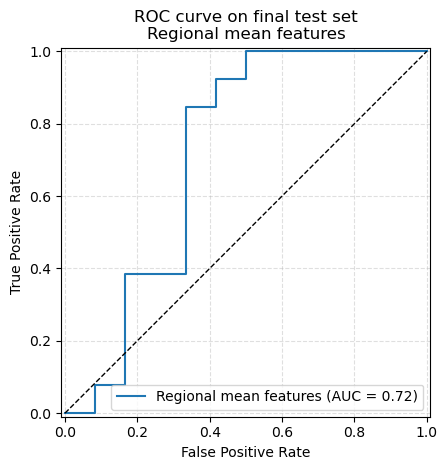

In [48]:
# ROC curve on the independent test set

plt.figure(figsize=(6, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=f"{best_feature_set_name}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Chance"
)

plt.title(
    f"ROC curve on final test set\n{best_feature_set_name}"
)

plt.grid(
    linestyle="--",
    alpha=0.4
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.tight_layout()
save_figure("2a_rf_best_feature_set_roc_curve.png")
plt.show()

Table saved to: outputs\tabs\2a_rf_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\2a_rf_best_feature_set_confusion_matrix.png


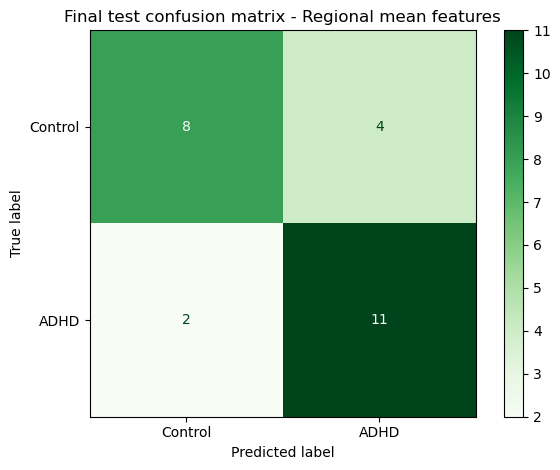

In [49]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1],
)

cm_df = pd.DataFrame(
    cm,
    index=["True Control", "True ADHD"],
    columns=["Predicted Control", "Predicted ADHD"]
)

save_table(
    cm_df,
    "2a_rf_best_feature_set_confusion_matrix.csv",
    index=True
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control", "ADHD"],
)

disp.plot(cmap="Greens")

plt.title(
    f"Final test confusion matrix - {best_feature_set_name}"
)

plt.tight_layout()
save_figure("2a_rf_best_feature_set_confusion_matrix.png")
plt.show()

In [50]:
classification_report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=["Control", "ADHD"],
    output_dict=True
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).T

save_table(
    classification_report_df,
    "2a_rf_best_feature_set_classification_report.csv",
    index=True
)

display(classification_report_df)

Table saved to: outputs\tabs\2a_rf_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.800000,0.666667,0.727273,12.00
ADHD,0.733333,0.846154,0.785714,13.00
accuracy,0.760000,0.760000,0.760000,0.76
macro avg,0.766667,0.756410,0.756494,25.00
weighted avg,0.765333,0.760000,0.757662,25.00


### 5. Features importance

After training the final Random Forest model, feature importance values were extracted to identify which EEG features contributed most to the classification.

Random Forest feature importance is based on the concept of **mean decrease in impurity**. Each decision tree in the forest splits the data into nodes. At each split, the algorithm selects the feature and threshold that best separate the two classes.

In classification trees, node impurity is commonly measured using the Gini impurity:

$$
Gini = 1 - \sum_{k=1}^{K} p_k^2
$$

where $K$ is the number of classes and $p_k$ is the proportion of samples belonging to class $k$ in that node.

In this project, the two classes are ADHD and Control, so the Gini impurity can be written as:

$$
Gini = 1 - p_{ADHD}^{2} - p_{Control}^{2}
$$

A feature is considered important if it is used in splits that strongly reduce impurity. The importance of a feature is obtained by summing the impurity decreases from all splits where that feature is used, weighted by the number of samples reaching each node.

For a Random Forest, the feature importance is averaged across all trees in the forest and normalized so that the sum of all feature importances is equal to 1.

Therefore, features with higher importance values are those that contributed more to reducing classification impurity across the forest.




In [51]:
importance_df = pd.DataFrame({
    "feature": best_feature_cols,
    "importance": final_rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

#display(importance_df.head(20))

In [52]:
importance_df["pretty_feature"] = importance_df["feature"].apply(
    pretty_feature_name
)

save_table(
    importance_df,
    "2a_rf_best_feature_set_feature_importance.csv"
)

Table saved to: outputs\tabs\2a_rf_best_feature_set_feature_importance.csv


Figure saved to: outputs\figures\2a_rf_best_feature_set_feature_importance_top10.png


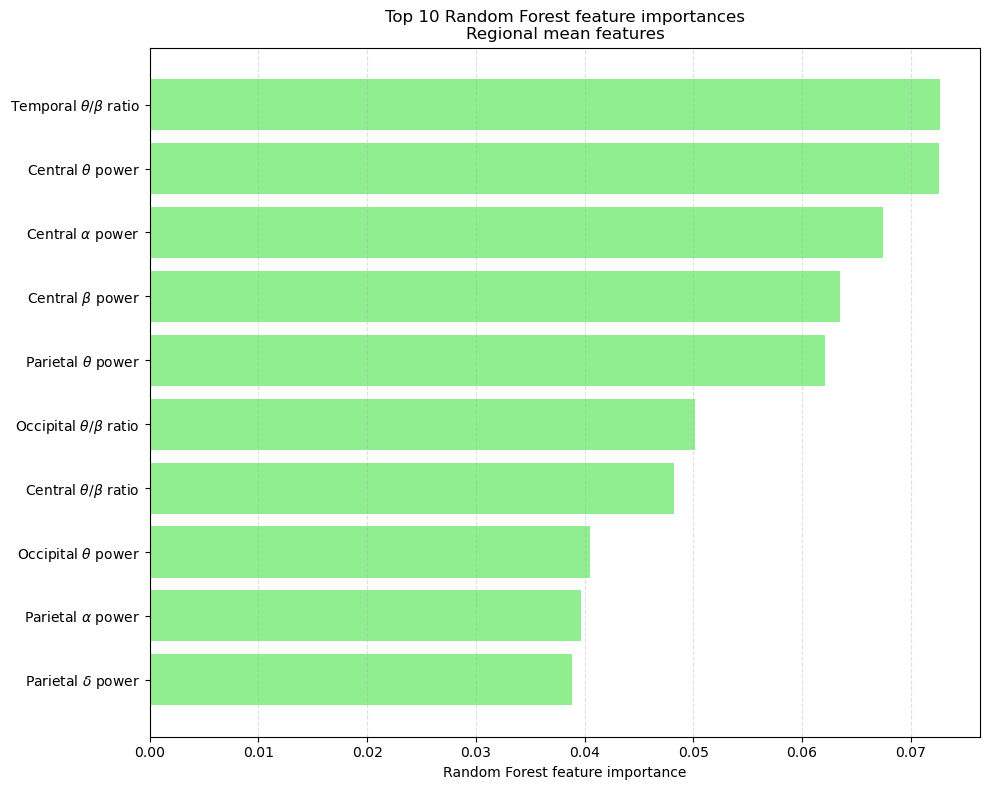

In [53]:
top_importance = importance_df.head(10).copy()

top_importance["pretty_feature"] = top_importance["feature"].apply(
    pretty_feature_name
)

plt.figure(figsize=(10, 8))

plt.xticks(np.arange(0, 0.1, 0.01))

plt.barh(
    top_importance["pretty_feature"],
    top_importance["importance"],
    color = 'lightgreen'
)

plt.xlabel("Random Forest feature importance")
plt.title(
    f"Top 10 Random Forest feature importances\n{best_feature_set_name}"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
save_figure("2a_rf_best_feature_set_feature_importance_top10.png")
plt.show()

Table saved to: outputs\tabs\2a_rf_top10_feature_importance_spearman_correlation.csv
Figure saved to: outputs\figures\2a_rf_top10_feature_importance_correlation_matrix.png


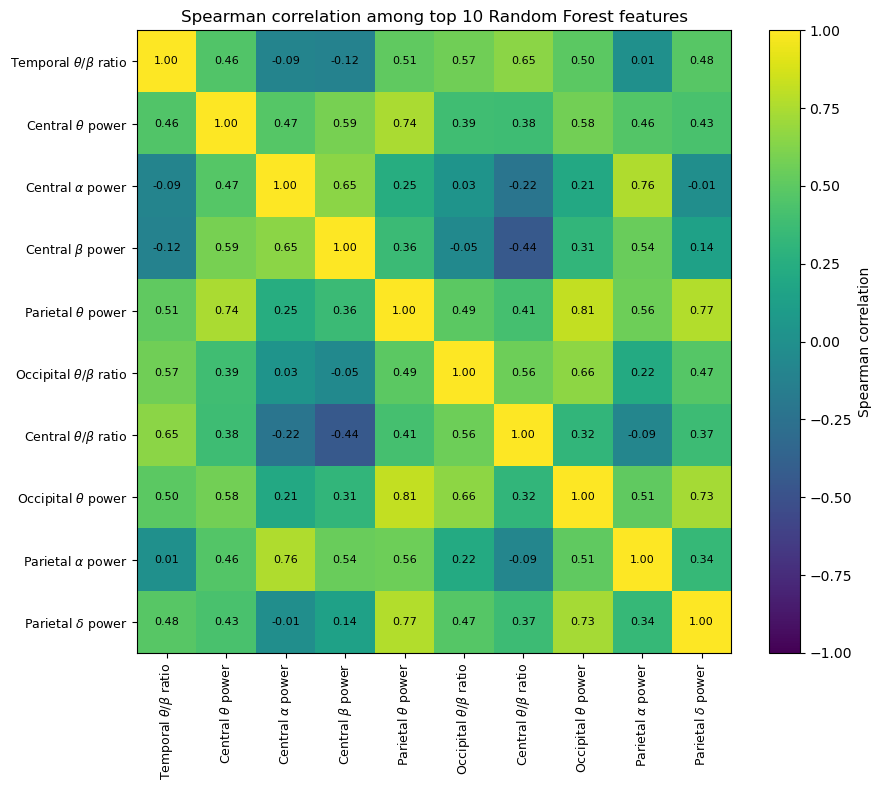

In [54]:
# Correlation matrix of the top 10 Random Forest features

top10_rf_features = importance_df.head(10)["feature"].tolist()

top10_rf_corr = train_df[top10_rf_features].corr(
    method="spearman"
)

top10_rf_corr_labels = [
    pretty_feature_name(feature)
    for feature in top10_rf_features
]

save_table(
    top10_rf_corr,
    "2a_rf_top10_feature_importance_spearman_correlation.csv",
    index=True
)

plt.figure(figsize=(9, 8))

plt.imshow(
    top10_rf_corr.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Spearman correlation")

plt.xticks(
    ticks=np.arange(len(top10_rf_corr_labels)),
    labels=top10_rf_corr_labels,
    rotation=90,
    fontsize=9
)

plt.yticks(
    ticks=np.arange(len(top10_rf_corr_labels)),
    labels=top10_rf_corr_labels,
    fontsize=9
)

for i in range(top10_rf_corr.shape[0]):
    for j in range(top10_rf_corr.shape[1]):

        value = top10_rf_corr.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Spearman correlation among top 10 Random Forest features")

plt.tight_layout()
save_figure("2a_rf_top10_feature_importance_correlation_matrix.png")
plt.show()